# Phase 3 — Machine Learning Model Development

Predicting Airbnb Rome nightly price from the Phase 1/2 cleaned, feature-engineered
dataset (`data/processed/listings_features.parquet`).

This notebook covers:
1. **Target treatment** — `log1p(price)` to tame the right-skewed price distribution
2. **Validation strategy** — spatial `GroupKFold` (grouped by neighbourhood) so no
   neighbourhood's listings leak across the train/validation split
3. **Model benchmarking** — Ridge baseline vs. LightGBM / XGBoost / CatBoost
4. **Evaluation** — RMSE, MAE, MdAPE, all reported in real dollar terms
5. **Reuse** — fitting a final model and a small helper to score new listings

All the reusable pipeline/CV/metric code lives in `src/phase3_model_training.py` —
this notebook imports it rather than redefining it, so the same functions can be
called from a plain script (see `python src/phase3_model_training.py` for a
command-line benchmark run).

In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import model_training as p3

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# Colorblind-safe categorical palette (Okabe-Ito), used in a fixed order throughout.
PALETTE = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7"]

## 1. Load the feature-engineered dataset

`phase3_model_training.load_model_frame()` reads the Phase 2 parquet output and
restricts it to a non-leaky, model-ready feature set: physical specs, amenity
flags, geospatial distances, host/market attributes, and the three categoricals
(`room_type`, `property_type`, `neighbourhood_cleansed`). Columns like the raw
price quote fields, free-text, and IDs are intentionally excluded — see the
`FEATURE_COLUMNS` definition in the module for the full rationale.

In [3]:
df = p3.load_model_frame()
df[["price"] + p3.NUMERIC_FEATURES[:6]].describe().round(1)

Model frame: 33,057 rows x 46 features.


,price,accommodates,bathrooms,bedrooms,beds,minimum_nights,maximum_nights
count,33057.0,33057.0,33044.0,33057.0,33057.0,33057.0,33057.0
mean,183.1,3.7,1.3,1.3,2.1,3.4,531.8
std,96.6,1.8,0.6,0.9,1.3,8.0,472.8
min,3.4,1.0,0.0,0.0,1.0,1.0,1.0
25%,116.8,2.0,1.0,1.0,1.0,1.0,30.0
50%,159.0,4.0,1.0,1.0,2.0,1.0,365.0
75%,223.0,4.0,1.0,2.0,3.0,2.0,1125.0
max,580.0,16.0,24.0,28.0,40.0,365.0,1125.0


## 2. Target treatment: `log1p(price)`

Airbnb nightly prices are heavily right-skewed (a long tail of high-end
villas/palazzos). Training directly on price lets a handful of expensive
listings dominate the loss. `log1p` compresses that tail and makes the
regression target closer to normally distributed — models are fit in log
space, then predictions are inverse-transformed (`expm1`) back to dollars
before any metric is computed, so evaluation stays in real dollar terms.

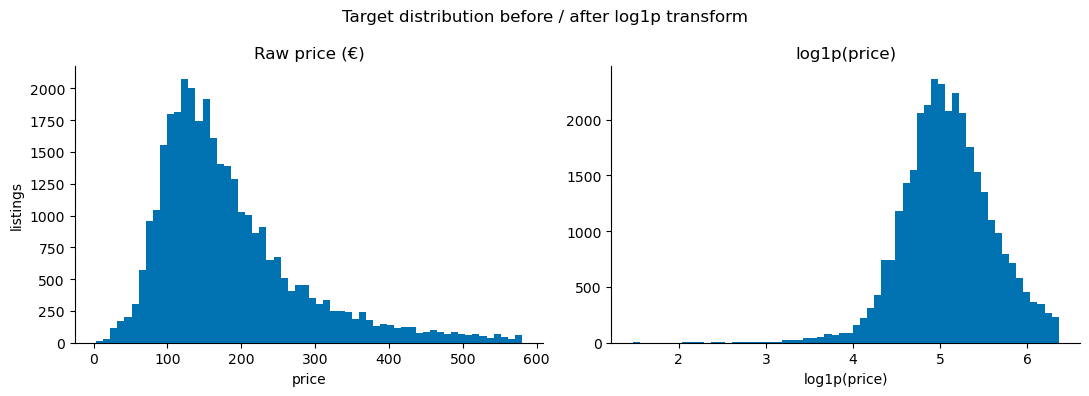

Raw price      skew: 1.41
log1p(price)   skew: -0.20


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(df["price"], bins=60, color=PALETTE[0])
axes[0].set_title("Raw price (\u20ac)")
axes[0].set_xlabel("price")
axes[0].set_ylabel("listings")

axes[1].hist(np.log1p(df["price"]), bins=60, color=PALETTE[0])
axes[1].set_title("log1p(price)")
axes[1].set_xlabel("log1p(price)")

fig.suptitle("Target distribution before / after log1p transform")
fig.tight_layout()
plt.show()

print(f"Raw price      skew: {df['price'].skew():.2f}")
print(f"log1p(price)   skew: {np.log1p(df['price']).skew():.2f}")

## 3. Validation strategy: spatial `GroupKFold` by neighbourhood

Nearby listings share neighbourhood-level price drivers (proximity to
attractions, local demand, building stock), so a random K-fold split would
leak that spatial signal between train and validation and overstate accuracy.
Instead we use **`GroupKFold(n_splits=5)`** grouped by `neighbourhood_cleansed`
(Rome's 15 official *municipi* — the same boundaries assigned in Phase 2 via
the `neighbourhoods.geojson` spatial join): every listing from a given
neighbourhood stays entirely on one side of each split.

One caveat worth seeing before trusting the numbers: **Rome's listings are
extremely spatially imbalanced** — *I Centro Storico* alone holds about half
of all listings. `GroupKFold` cannot split a single neighbourhood across
folds, so one fold will inevitably be large and dominated by the historic
centre while the rest share the remaining, quieter neighbourhoods. That's a
real property of the data (and the correct trade-off for avoiding leakage),
not a bug — the per-fold metrics printed during benchmarking make the effect
visible rather than hiding it behind an average.

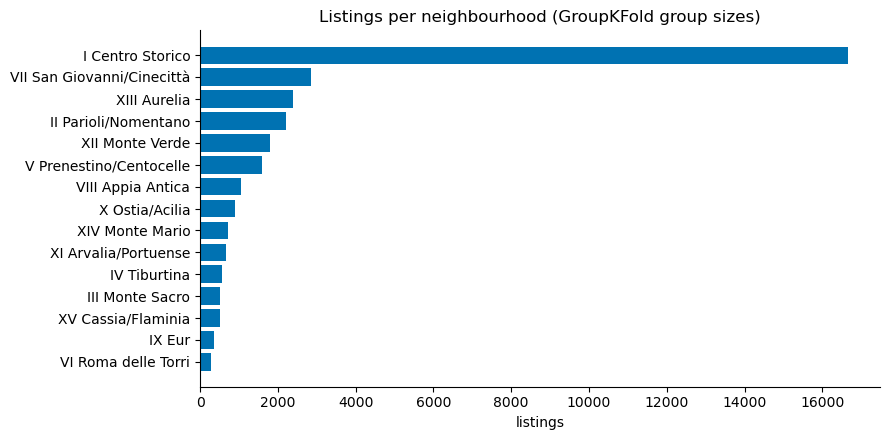

'I Centro Storico' alone holds 50% of all listings.


In [5]:
counts = df[p3.GROUP_COL].value_counts().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(counts.index[::-1], counts.values[::-1], color=PALETTE[0])
ax.set_xlabel("listings")
ax.set_title("Listings per neighbourhood (GroupKFold group sizes)")
fig.tight_layout()
plt.show()

print(f"{counts.index[0]!r} alone holds {counts.iloc[0] / len(df):.0%} of all listings.")

## 4. Model benchmarking: Ridge vs. LightGBM / XGBoost / CatBoost

`p3.run_benchmark()` runs every model in `p3.get_models()` through the same
spatial 5-fold CV: for each fold it fits a fresh `preprocess -> model`
pipeline on the training neighbourhoods, predicts on the held-out
neighbourhoods, inverse-transforms back to dollars, and scores RMSE / MAE /
MdAPE. This takes roughly a minute or two on the full dataset.

In [6]:
summary, results = p3.run_benchmark(df, n_splits=5)
summary.round(2)


Ridge
  fold 1/5 (n=16649, 1 neighbourhoods held out): RMSE=92.10  MAE=55.43  MdAPE=20.2%
  fold 2/5 (n= 4069, 3 neighbourhoods held out): RMSE=56.43  MAE=34.99  MdAPE=18.6%
  fold 3/5 (n= 4208, 4 neighbourhoods held out): RMSE=67.76  MAE=45.15  MdAPE=23.0%
  fold 4/5 (n= 3936, 3 neighbourhoods held out): RMSE=57.58  MAE=38.67  MdAPE=21.0%
  fold 5/5 (n= 4195, 4 neighbourhoods held out): RMSE=48.55  MAE=32.81  MdAPE=21.0%

LightGBM
  fold 1/5 (n=16649, 1 neighbourhoods held out): RMSE=71.19  MAE=48.34  MdAPE=17.2%
  fold 2/5 (n= 4069, 3 neighbourhoods held out): RMSE=54.25  MAE=32.27  MdAPE=15.6%
  fold 3/5 (n= 4208, 4 neighbourhoods held out): RMSE=53.49  MAE=34.80  MdAPE=17.3%
  fold 4/5 (n= 3936, 3 neighbourhoods held out): RMSE=53.98  MAE=34.26  MdAPE=17.1%
  fold 5/5 (n= 4195, 4 neighbourhoods held out): RMSE=45.08  MAE=29.06  MdAPE=17.5%

XGBoost
  fold 1/5 (n=16649, 1 neighbourhoods held out): RMSE=72.43  MAE=49.22  MdAPE=17.6%
  fold 2/5 (n= 4069, 3 neighbourhoods held out): R

,RMSE_mean,RMSE_std,MAE_mean,MAE_std,MdAPE_mean,MdAPE_std
model,,,,,,
Ridge,64.48,16.88,41.41,9.13,20.77,1.60
LightGBM,55.60,9.52,35.75,7.39,16.95,0.75
XGBoost,55.78,9.99,35.82,7.79,16.89,0.80
CatBoost,57.12,11.72,36.56,8.83,16.97,0.98


## 5. Results comparison

Bars show the mean of each metric across the 5 folds; the error bar is the
fold-to-fold standard deviation (a proxy for how sensitive each model is to
*which* neighbourhoods happened to be held out).

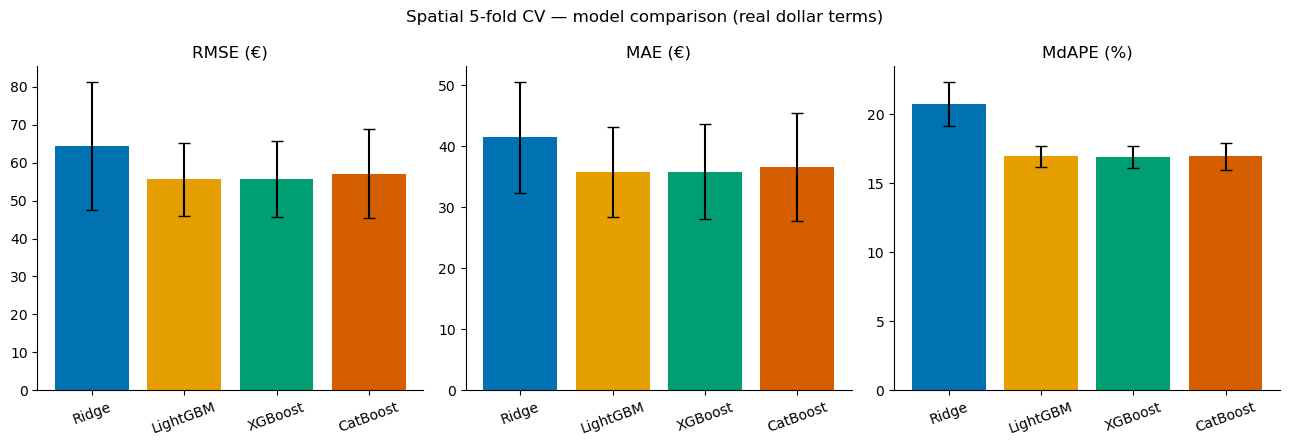

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
metrics = [("RMSE", "\u20ac"), ("MAE", "\u20ac"), ("MdAPE", "%")]

for ax, (metric, unit) in zip(axes, metrics):
    means = summary[f"{metric}_mean"]
    stds = summary[f"{metric}_std"]
    ax.bar(means.index, means.values, yerr=stds.values, capsize=4,
           color=PALETTE[: len(means)])
    ax.set_title(f"{metric} ({unit})")
    ax.tick_params(axis="x", rotation=20)

fig.suptitle("Spatial 5-fold CV — model comparison (real dollar terms)")
fig.tight_layout()
plt.show()

Best model by mean MAE: LightGBM


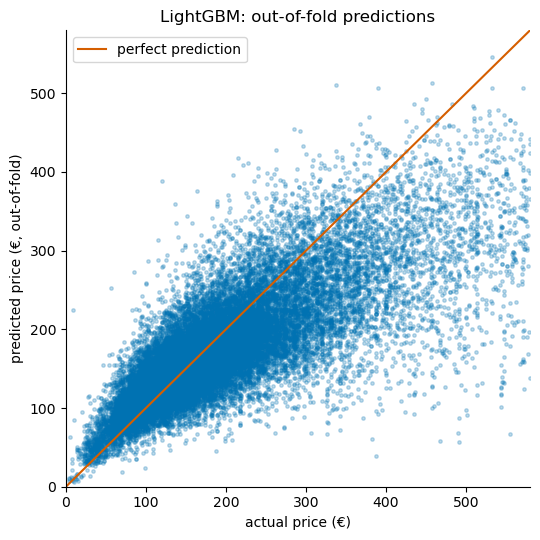

In [8]:
best_model_name = summary["MAE_mean"].idxmin()
print(f"Best model by mean MAE: {best_model_name}")

best = results[best_model_name]
mask = ~np.isnan(best.oof_pred)

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(best.oof_true[mask], best.oof_pred[mask], s=6, alpha=0.25, color=PALETTE[0])
lims = [0, max(best.oof_true[mask].max(), best.oof_pred[mask].max())]
ax.plot(lims, lims, color=PALETTE[3], linewidth=1.5, label="perfect prediction")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("actual price (\u20ac)")
ax.set_ylabel("predicted price (\u20ac, out-of-fold)")
ax.set_title(f"{best_model_name}: out-of-fold predictions")
ax.legend()
fig.tight_layout()
plt.show()

### Error breakdown by neighbourhood

Since the CV is grouped spatially, it's worth checking whether error is
concentrated in specific neighbourhoods (e.g. the historic centre's larger,
noisier price distribution) rather than spread evenly.

In [9]:
oof_df = df[[p3.GROUP_COL, "price"]].copy()
oof_df["pred"] = best.oof_pred
oof_df["abs_pct_error"] = (oof_df["price"] - oof_df["pred"]).abs() / oof_df["price"]

by_neighbourhood = (
    oof_df.groupby(p3.GROUP_COL, observed=True)
    .agg(n=("price", "size"), MdAPE=("abs_pct_error", "median"))
    .assign(MdAPE=lambda d: (d["MdAPE"] * 100).round(1))
    .sort_values("MdAPE", ascending=False)
)
by_neighbourhood

,n,MdAPE
neighbourhood_cleansed,,
X Ostia/Acilia,892,20.4
XV Cassia/Flaminia,508,20.0
IX Eur,355,19.9
VI Roma delle Torri,292,19.5
IV Tiburtina,570,18.1
V Prenestino/Centocelle,1584,18.1
XI Arvalia/Portuense,662,17.9
III Monte Sacro,513,17.8
I Centro Storico,16649,17.2


## 6. Final model + testing it on new data

For deployment/reuse we refit the best-performing model on **all** available
data (no held-out fold) and persist the full `preprocess -> model` pipeline
with `joblib`, so scoring a new listing later doesn't require re-deriving the
preprocessing by hand.

In [10]:
import joblib
from sklearn.pipeline import Pipeline

final_model = p3.get_models()[best_model_name]
final_pipeline = Pipeline([
    ("preprocess", p3.build_preprocessor()),
    ("model", final_model),
])
final_pipeline.fit(df[p3.FEATURE_COLUMNS], np.log1p(df[p3.TARGET_COL]))

MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(exist_ok=True)
model_path = MODEL_DIR / "price_model.joblib"
joblib.dump(final_pipeline, model_path)
print(f"Saved fitted pipeline ({best_model_name}) to {model_path}")

Saved fitted pipeline (LightGBM) to /home/matthew/code/notebooks/personal/airbnb_rome/models/price_model.joblib


### Test it: score listings and compute metrics on demand

`predict_price` scores raw listing rows (same schema as
`data/processed/listings_features.parquet`) in real dollars. `evaluate` runs
those predictions against known prices and reports RMSE / MAE / MdAPE — reuse
this on any held-out slice (a fresh scrape, a manual test set, etc.) without
duplicating the metric logic.

In [11]:
def predict_price(pipeline: Pipeline, listings: pd.DataFrame) -> np.ndarray:
    """Predict nightly price (EUR) for rows shaped like the Phase 2 feature table."""
    log_pred = pipeline.predict(listings[p3.FEATURE_COLUMNS])
    return np.clip(np.expm1(log_pred), 0, None)


def evaluate(pipeline: Pipeline, listings: pd.DataFrame) -> dict:
    """Predict + score against the true `price` column, in real dollar terms."""
    preds = predict_price(pipeline, listings)
    return p3.dollar_metrics(listings[p3.TARGET_COL].to_numpy(), preds)


# Demo: a handful of listings, predicted vs. actual.
sample = df.sample(5, random_state=0)
sample_preds = predict_price(final_pipeline, sample)
pd.DataFrame({
    "actual_price": sample["price"].values,
    "predicted_price": sample_preds.round(1),
}, index=sample.index)

,actual_price,predicted_price
7994,141.0,154.4
7053,183.0,207.7
21825,102.0,109.9
26928,184.0,192.2
21678,194.0,192.7


In [12]:
# Reload from disk and confirm it reproduces the same metrics as training data
# (swap `df` for any new/held-out DataFrame with the same feature columns to
# test the model on data it hasn't seen).
loaded_pipeline = joblib.load(model_path)
evaluate(loaded_pipeline, df)

{'RMSE': 51.034150550941796,
 'MAE': 33.448015567518944,
 'MdAPE': 14.28967809542994}